## <center> Prelims 2023
### <center> Mani Tyagi
#### <center> 200973108

In [89]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate

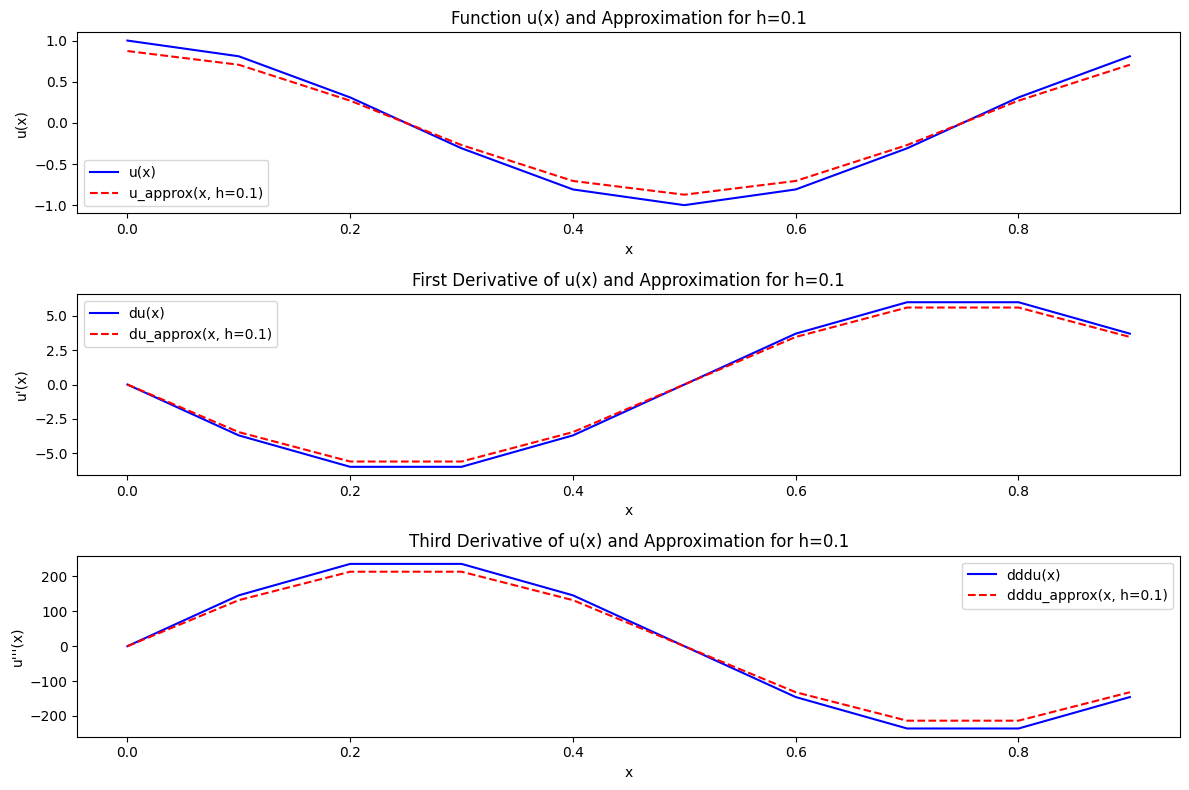

Errors for h = 0.1:
Max error in u:  0.1273220037500351
Max error in du:  0.38549438573363837
Max error in dddu:  22.38428030037636




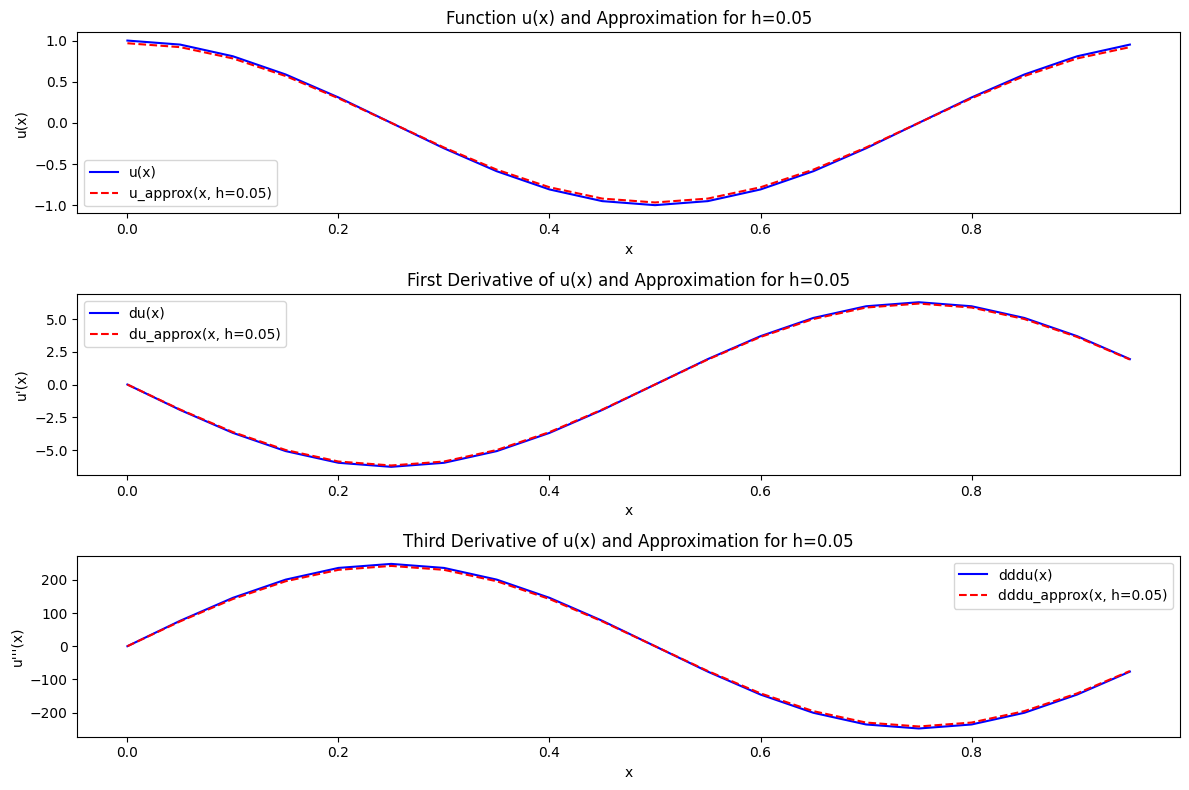

Errors for h = 0.05:
Max error in u:  0.03262898913656431
Max error in du:  0.1028454196806381
Max error in dddu:  6.060321783024904




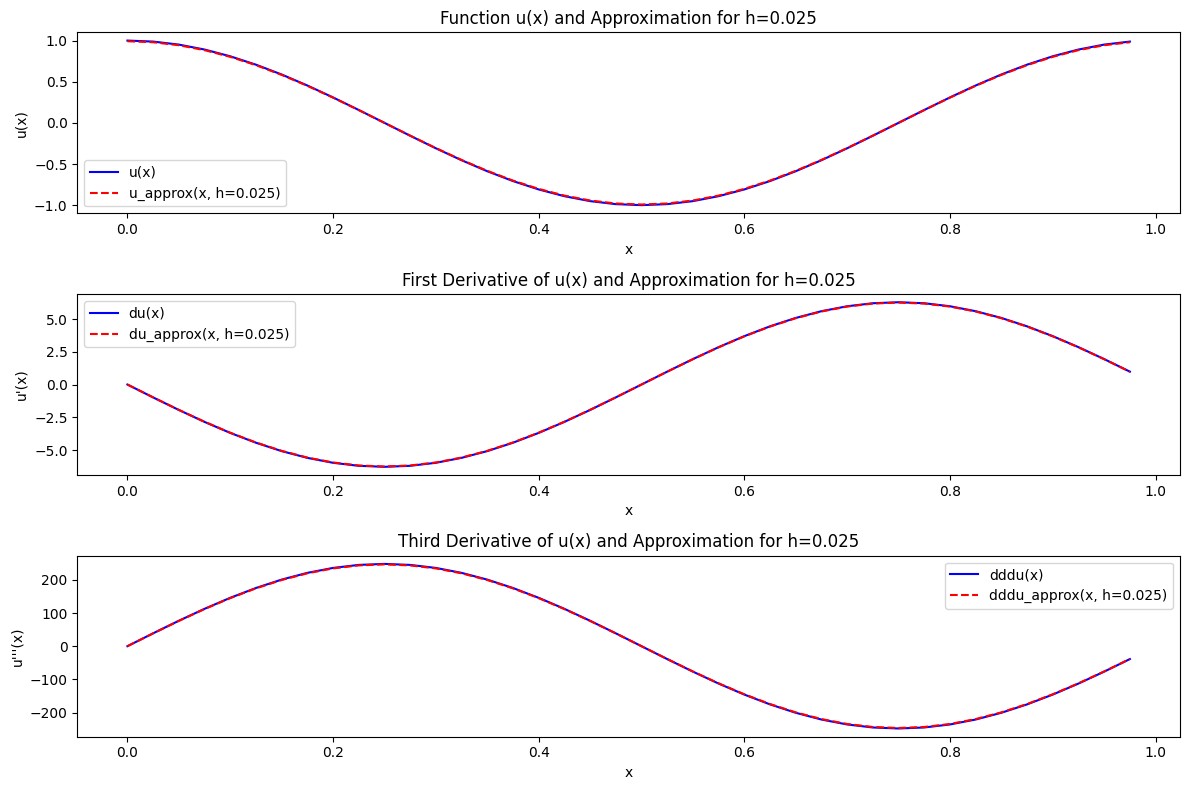

Errors for h = 0.025:
Max error in u:  0.00820777293657482
Max error in du:  0.025806705570352584
Max error in dddu:  1.52632828948245




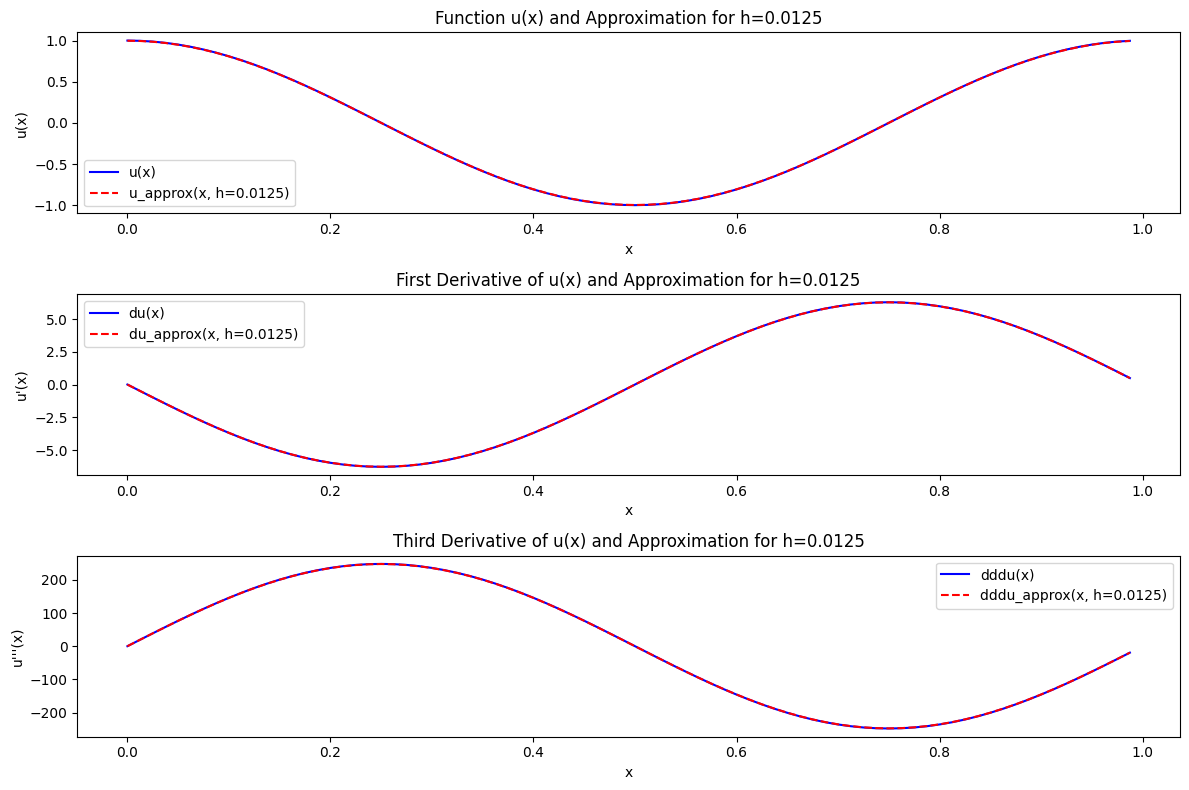

Errors for h = 0.0125:
Max error in u:  0.0020551108445813204
Max error in du:  0.006457648952026496
Max error in dddu:  0.38228872782892154




In [90]:
# Define the function u(x) and its derivatives
def u(x):
    return np.cos(2 * np.pi * x)

def du(x):
    return -2 * np.pi * np.sin(2 * np.pi * x)

def dddu(x):
    return 8 * (np.pi**3) * np.sin(2 * np.pi * x)

# Define the approximate functions with periodicity adjustment
def u_approx(x, h):
    return (1 / 3) * (u((x + h) % 1) + u(x) + u((x - h) % 1))

def du_approx(x, h):
    return (1 / (2 * h)) * (u((x + h) % 1) - u((x - h) % 1))

def dddu_approx(x, h):
    return (1 / (2 * h**3)) * (u((x + 2 * h) % 1) - 2 * u((x + h) % 1) + 2 * u((x - h) % 1) - u((x - 2 * h) % 1))

# Define the interval and the range of h values
interval = (0, 1)
h_values = [0.1, 0.05, 0.025, 0.0125]

# Create a function to compute the errors for each h
def compute_errors(h):
    x_values = np.arange(interval[0], interval[1], h)
    u_errors = []
    du_errors = []
    dddu_errors = []
    for x in x_values:
        u_error = np.abs(u(x) - u_approx(x, h))
        du_error = np.abs(du(x) - du_approx(x, h))
        dddu_error = np.abs(dddu(x) - dddu_approx(x, h))
        u_errors.append(u_error)
        du_errors.append(du_error)
        dddu_errors.append(dddu_error)
    return x_values, u_errors, du_errors, dddu_errors

# Plot the results for each h
for h in h_values:
    x_values, u_errors, du_errors, dddu_errors = compute_errors(h)
    
    plt.figure(figsize=(12, 8))
    
    # Plot for u and its approximation error
    plt.subplot(3, 1, 1)
    plt.plot(x_values, u(x_values), 'b-', label='u(x)')
    plt.plot(x_values, u_approx(x_values, h), 'r--', label=f'u_approx(x, h={h})')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.legend()
    plt.title(f'Function u(x) and Approximation for h={h}')
    
    # Plot for du and its approximation error
    plt.subplot(3, 1, 2)
    plt.plot(x_values, du(x_values), 'b-', label='du(x)')
    plt.plot(x_values, du_approx(x_values, h), 'r--', label=f'du_approx(x, h={h})')
    plt.xlabel('x')
    plt.ylabel("u'(x)")
    plt.legend()
    plt.title(f"First Derivative of u(x) and Approximation for h={h}")
    
    # Plot for dddu and its approximation error
    plt.subplot(3, 1, 3)
    plt.plot(x_values, dddu(x_values), 'b-', label='dddu(x)')
    plt.plot(x_values, dddu_approx(x_values, h), 'r--', label=f'dddu_approx(x, h={h})')
    plt.xlabel('x')
    plt.ylabel("u'''(x)")
    plt.legend()
    plt.title(f"Third Derivative of u(x) and Approximation for h={h}")
    
    plt.tight_layout()
    plt.show()
    
    # Print errors
    print(f"Errors for h = {h}:")
    print("Max error in u: ", np.max(u_errors))
    print("Max error in du: ", np.max(du_errors))
    print("Max error in dddu: ", np.max(dddu_errors))
    print("\n")


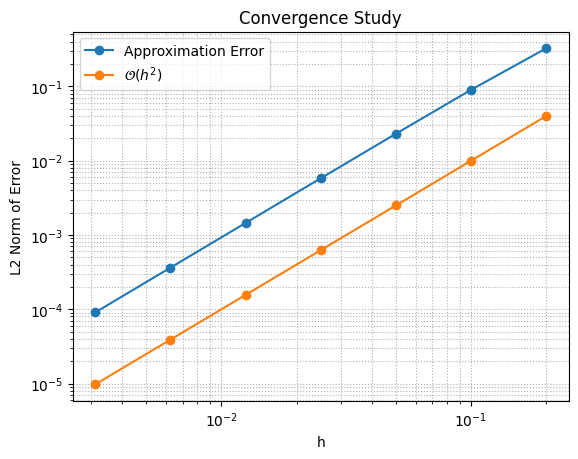

+----------+-------------+--------------------+
|        h |       Error |   Convergence Rate |
+==========+=============+====================+
| 0.2      | 0.325733    |                    |
+----------+-------------+--------------------+
| 0.1      | 0.0900303   |            1.85521 |
+----------+-------------+--------------------+
| 0.05     | 0.0230722   |            1.96426 |
+----------+-------------+--------------------+
| 0.025    | 0.00580377  |            1.99109 |
+----------+-------------+--------------------+
| 0.0125   | 0.00145318  |            1.99777 |
+----------+-------------+--------------------+
| 0.00625  | 0.000363436 |            1.99944 |
+----------+-------------+--------------------+
| 0.003125 | 9.08677e-05 |            1.99986 |
+----------+-------------+--------------------+


In [91]:
# Define the interval and the range of h values
interval = (0, 1)
h_values = [0.2, 0.1, 0.05, 0.025, 0.0125, 0.00625, 0.003125]

# Function to compute the L2 norm of the error
def compute_error(h):
    x_values = np.arange(interval[0], interval[1], h)
    errors = []
    for x in x_values:
        exact = u(x)
        approx = u_approx(x, h)
        error = np.abs(exact - approx)

        errors.append(error)
    return np.sqrt(np.sum(np.array(errors)**2) * h)

# Compute the errors for each h
errors = []
Oh2 = []
for h in h_values:
    h2 = h**2
    Oh2.append(h2)
    error = compute_error(h)
    errors.append(error)

# Plotting the errors
plt.loglog(h_values, errors, marker='o', label='Approximation Error')
plt.loglog(h_values, Oh2, marker='o', label='$\mathcal{O}(h^2)$')
plt.xlabel('h')
plt.ylabel('L2 Norm of Error')
plt.title('Convergence Study')
plt.legend()
plt.grid(True, which="both", ls=":")
plt.show()

# Compute the convergence rate
convergence_rates = []
for i in range(1, len(errors)):
    rate = np.log(errors[i]/errors[i-1]) / np.log(h_values[i]/h_values[i-1])
    convergence_rates.append(rate)

# Create a table to display the results
table = []
for i in range(len(h_values)):
    if i == 0:
        table.append([h_values[i], errors[i], None])
    else:
        table.append([h_values[i], errors[i], convergence_rates[i-1]])

# Print the table
print(tabulate(table, headers=['h', 'Error', 'Convergence Rate'], tablefmt='grid'))


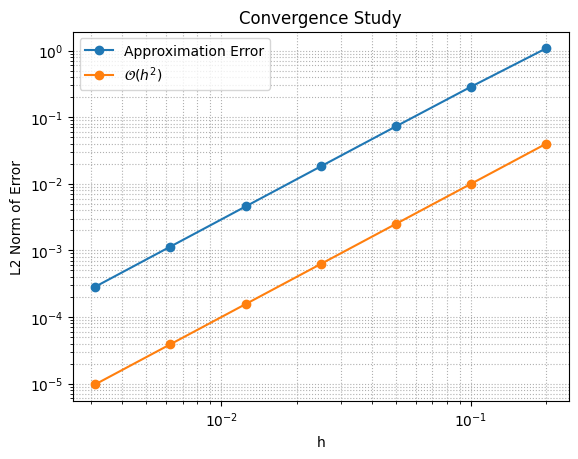

------------------------------------------------------------
h          Error                     Convergence Rate         
------------------------------------------------------------
0.2        1.08039037833858          -                        
0.1        0.2866135603838321        1.914373923034325        
0.05       0.07272269367015423       1.978629325135248        
0.025      0.01824809650887729       1.9946596565966497       
0.0125     0.0045662473644806235     1.9986650607634446       
0.00625    0.0011418259388745295     1.9996662743616465       
0.003125   0.000285472993072444      1.9999165693098349       
------------------------------------------------------------


In [92]:
# Define the interval and the range of h values
interval = (0, 1)
h_values = [0.2, 0.1, 0.05, 0.025, 0.0125, 0.00625, 0.003125]

# Function to compute the L2 norm of the error
def compute_error(h):
    x_values = np.arange(interval[0], interval[1], h)
    errors = []
    for x in x_values:
        exact = du(x)
        approx = du_approx(x, h)
        error = np.abs(exact - approx)
        errors.append(error)
    return np.sqrt(np.sum(np.array(errors)**2) * h)

# Compute the errors for each h
errors = []
Oh2 = []
for h in h_values:
    h2 = h**2
    Oh2.append(h2)
    error = compute_error(h)
    errors.append(error)

# Plotting the errors
plt.loglog(h_values, errors, marker='o', label='Approximation Error')
plt.loglog(h_values, Oh2, marker='o', label='$\mathcal{O}(h^2)$')
plt.xlabel('h')
plt.ylabel('L2 Norm of Error')
plt.title('Convergence Study')
plt.legend()
plt.grid(True, which="both", ls=":")
plt.show()

# Compute the convergence rate
convergence_rates = []
for i in range(1, len(errors)):
    rate = np.log(errors[i]/errors[i-1]) / np.log(h_values[i]/h_values[i-1])
    convergence_rates.append(rate)

print("-"*60)
print(f"{'h':<10} {'Error':<25} {'Convergence Rate':<25}")
print("-"*60)
for i in range(len(h_values)):
    if i == 0:
        print(f"{h_values[i]:<10} {errors[i]:<25} {'-':<25}")
    else:
        print(f"{h_values[i]:<10} {errors[i]:<25} {convergence_rates[i-1]:<25}")
print("-"*60)


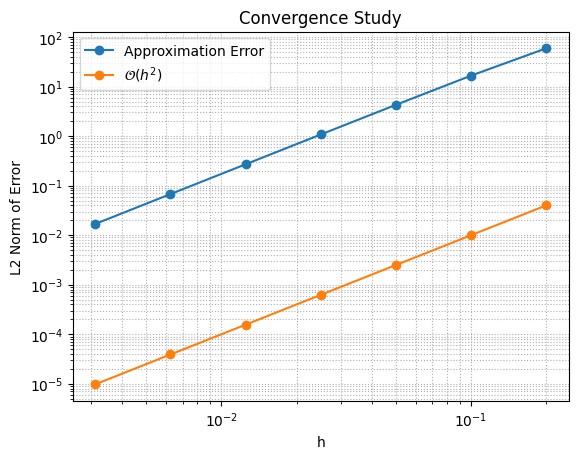

------------------------------------------------------------
h          Error                     Convergence Rate         
------------------------------------------------------------
0.2        59.22672723108289         -                        
0.1        16.642624408941064        1.8313654145407932       
0.05       4.285294628948147         1.9574166497282988       
0.025      1.0792770838052155        1.9893291012498429       
0.0125     0.27031895161044284       1.9973307313405988       
0.00625    0.06761100883038859       1.9993325813441527       
0.003125   0.01690469958693322       1.9998337955471437       
------------------------------------------------------------


In [93]:
# Define the interval and the range of h values
interval = (0, 1)
h_values = [0.2, 0.1, 0.05, 0.025, 0.0125, 0.00625, 0.003125]

# Function to compute the L2 norm of the error
def compute_error(h):
    x_values = np.arange(interval[0], interval[1], h)
    errors = []
    for x in x_values:
        exact = dddu(x)
        approx = dddu_approx(x, h)
        error = np.abs(exact - approx)
        errors.append(error)
    return np.sqrt(np.sum(np.array(errors)**2) * h)

# Compute the errors for each h
errors = []
Oh2 = []
for h in h_values:
    h2 = h**2
    Oh2.append(h2)
    error = compute_error(h)
    errors.append(error)

# Plotting the errors
plt.loglog(h_values, errors, marker='o', label='Approximation Error')
plt.loglog(h_values, Oh2, marker='o', label='$\mathcal{O}(h^2)$')
plt.xlabel('h')
plt.ylabel('L2 Norm of Error')
plt.title('Convergence Study')
plt.legend()
plt.grid(True, which="both", ls=":")
plt.show()

# Compute the convergence rate
convergence_rates = []
for i in range(1, len(errors)):
    rate = np.log(errors[i]/errors[i-1]) / np.log(h_values[i]/h_values[i-1])
    convergence_rates.append(rate)

print("-"*60)
print(f"{'h':<10} {'Error':<25} {'Convergence Rate':<25}")
print("-"*60)
for i in range(len(h_values)):
    if i == 0:
        print(f"{h_values[i]:<10} {errors[i]:<25} {'-':<25}")
    else:
        print(f"{h_values[i]:<10} {errors[i]:<25} {convergence_rates[i-1]:<25}")
print("-"*60)

### Part (c)

In [94]:
# Define the function u(x) and its derivatives
def u(x):
    return np.cos(2 * np.pi * x)

def du(x):
    return -2 * np.pi * np.sin(2 * np.pi * x)

def dddu(x):
    return 8 * (np.pi**3) * np.sin(2 * np.pi * x)

# Define the approximate functions with periodicity adjustment
def u_approx(x, h):
    return (1 / 3) * (u((x + h) % (2*np.pi)) + u(x) + u((x - h) % (2 * np.pi)))

def du_approx(x, h):
    return (1 / (2 * h)) * (u((x + h)% (2*np.pi)) - u((x - h)% (2*np.pi)))

def dddu_approx(x, h):
    return (1 / (2 * h**3)) * (u((x + 2 * h) % (2*np.pi)) - 2 * u((x + h) % (2*np.pi)) + 2 * u((x - h) % (2*np.pi)) - u((x - 2 * h) % (2*np.pi)))

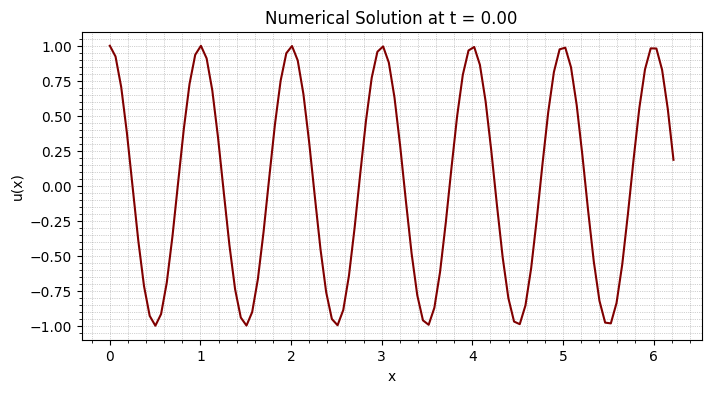

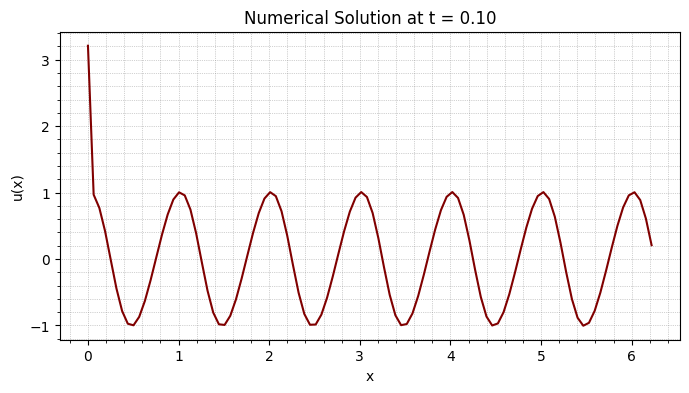

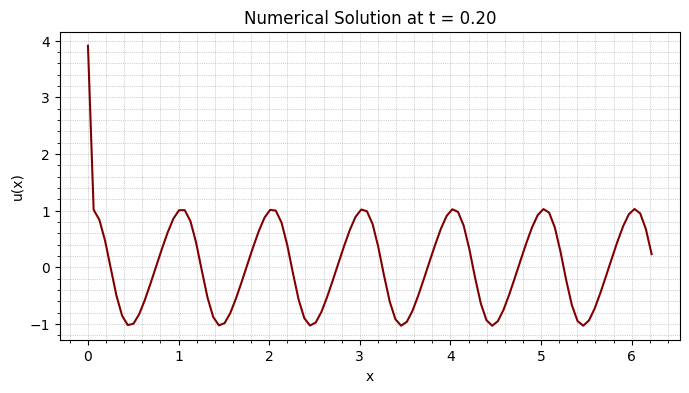

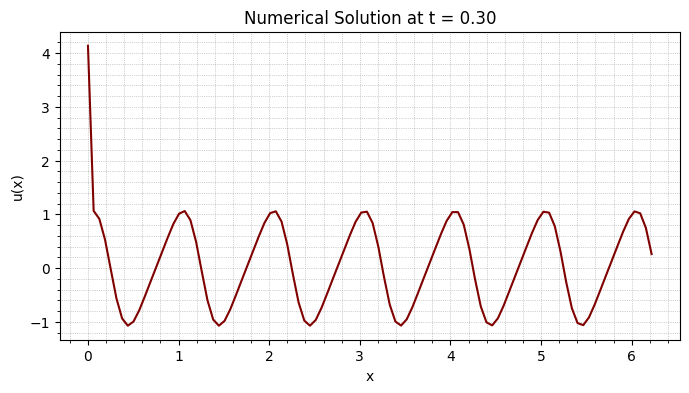

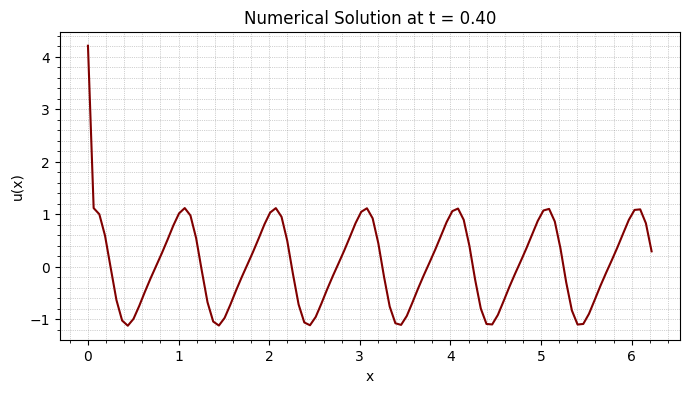

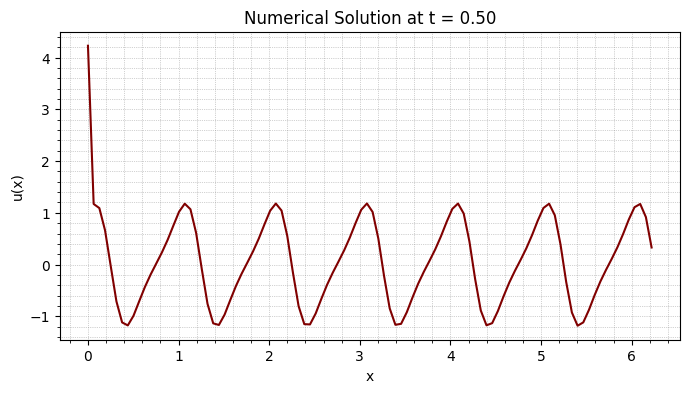

In [97]:
# Define the parameters
delta = 0.02
T = 0.5
L = 2 * np.pi
Nx = 100
Nt = 1000
h = 0.01
dt = 10e-5

# Initialize the solution array
x = np.linspace(0, L, Nx, endpoint=False)
u_values = np.zeros((Nt+1, Nx))

# Set initial condition
u_values[0] = u(x)

# Time-stepping using forward Euler
for n in range(Nt):
    u_xx = dddu_approx(x, h)
    u_values[n+1] = u_values[n] - dt * (u_values[n] * du_approx(x, h) + delta**2 * u_xx)

# Plot the solution at different time steps
num_plots = 6  # Number of plots to create
time_steps = np.linspace(0, T, num_plots)
for i, t in enumerate(time_steps):
    plt.figure(figsize=(8, 4))
    plt.plot(x, u_values[int(Nt * t / T)], color ='maroon')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.title(f'Numerical Solution at t = {t:.2f}')
    plt.minorticks_on()
    plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
    plt.show()


